In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

/data/shared/fsibilla/wfp-downscaling/.mamba/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_DIR = Path("/data/shared/fsibilla/clean_code/Q1/experiments")
OUTPUT_DIR = Path('/data/shared/fsibilla/clean_code/Q1/decision_supp_model')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

BASE_DIR

PosixPath('/data/shared/fsibilla/clean_code/Q1/experiments')

In [3]:
EVAL_PATTERN = re.compile(r"eval_adm1_seed_metrics_train_(\d+)\.csv$")
TRAIN_PATTERN = re.compile(r"train_subset_(\d+)_seed(\d+)\.csv$")


def extract_psu_from_eval(path: Path):
    m = EVAL_PATTERN.search(path.name)
    return int(m.group(1)) if m else None


def extract_psu_seed_from_train(path: Path):
    m = TRAIN_PATTERN.search(path.name)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None


def detect_adm1_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

In [5]:
import unicodedata

ADM1_CANDIDATES = ["adm1_name", "adm1name"]

def norm_place(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.replace("’","'").replace("‘","'").replace("`","'")
    s = re.sub(r"[^a-z0-9\s']", " ", s)
    s = s.replace("'", "")
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\bgovernorate\b", "", s).strip()
    return s

def _finite_1d(x):
    x = np.asarray(x, dtype=float).ravel()
    return x[np.isfinite(x)]

def emd_density_1d(x, y, bins=200, value_range=None, clip_quantiles=(0.0, 1.0)):
    x = _finite_1d(x)
    y = _finite_1d(y)
    if len(x) == 0 or len(y) == 0:
        return np.nan

    if value_range is None:
        z = np.concatenate([x, y])
        qlo, qhi = clip_quantiles
        lo = np.quantile(z, qlo) if qlo > 0 else np.min(z)
        hi = np.quantile(z, qhi) if qhi < 1 else np.max(z)
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            lo, hi = float(np.min(z)), float(np.max(z))
        if hi <= lo:
            return 0.0
        value_range = (float(lo), float(hi))

    hx, edges = np.histogram(x, bins=bins, range=value_range, density=True)
    hy, _ = np.histogram(y, bins=edges, density=True)

    dx = np.diff(edges)
    px = hx * dx
    py = hy * dx
    cdf_x = np.cumsum(px)
    cdf_y = np.cumsum(py)

    return float(np.sum(np.abs(cdf_x - cdf_y) * dx))


def compute_train_intrinsic_for_file(train_path: Path, seed: int, variables):
    """
    Returns a dataframe with columns:
    seed, adm1, variable, variability_intrinsic_train
    computed inside the training subsample only.
    """
    try:
        trn = pd.read_csv(train_path)
    except Exception as e:
        print(f"Skipping train file {train_path} because of read error: {e}")
        return pd.DataFrame(columns=["seed", "adm1", "variable", "variability_intrinsic_train"])

    adm1_col = detect_adm1_col(trn, ADM1_CANDIDATES)
    if adm1_col is None:
        print(f"Skipping train file {train_path}: no adm1 column found")
        return pd.DataFrame(columns=["seed", "adm1", "variable", "variability_intrinsic_train"])

    trn = trn.copy()
    trn["adm1"] = trn[adm1_col].astype(str)
    trn["_adm1_norm"] = trn["adm1"].map(norm_place)

    rows = []
    bins = 200
    clip_q = (0.0, 1.0)

    for var in variables:
        if var not in trn.columns:
            continue

        x_nat = trn[var].values

        # same logic as your original code: shared range within the dataset used here
        z = _finite_1d(x_nat)
        if len(z) == 0:
            continue

        lo = np.quantile(z, clip_q[0]) if clip_q[0] > 0 else float(np.min(z))
        hi = np.quantile(z, clip_q[1]) if clip_q[1] < 1 else float(np.max(z))
        vr = (lo, hi) if np.isfinite(lo) and np.isfinite(hi) and hi > lo else None

        for adm1_val, grp in trn.groupby("adm1", dropna=False):
            x_adm1 = grp[var].values
            val = emd_density_1d(x_adm1, x_nat, bins=bins, value_range=vr, clip_quantiles=clip_q)

            rows.append({
                "seed": seed,
                "adm1": str(adm1_val),
                "_adm1_norm": norm_place(adm1_val),
                "variable": str(var),
                "variability_intrinsic_train": val
            })

    return pd.DataFrame(rows)

In [7]:
eval_rows = []

eval_files = sorted(BASE_DIR.glob("*/results/evaluation/eval_adm1_seed_metrics_train_*.csv"))
print(f"Found {len(eval_files)} evaluation files")

# cache so the same train file is not recomputed many times
train_intrinsic_cache = {}

for f in tqdm(eval_files):
    experiment = f.parts[-4]  # .../experiments/{experiment}/results/evaluation/file.csv
    psu_num = extract_psu_from_eval(f)
    if psu_num is None:
        continue

    try:
        df = pd.read_csv(f)
    except Exception as e:
        print(f"Skipping eval file {f} because of read error: {e}")
        continue

    required_cols = ["seed", "target", "emd_gen", "emd_nat", "variability_intrinsic"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"Skipping eval file {f} because missing columns: {missing}")
        continue

    adm1_name_col = detect_adm1_col(df, ["adm1_name", "adm1name", "adm1_code", "Code_adm1"])
    adm1_code_col = detect_adm1_col(df, ["adm1_code", "Code_adm1"])

    if adm1_name_col is None:
        print(f"Skipping eval file {f}: no adm1 column found")
        continue

    tmp = df.copy()
    tmp["experiment"] = experiment
    tmp["psu_num"] = psu_num
    tmp["adm1"] = tmp[adm1_name_col].astype(str)
    tmp["_adm1_norm"] = tmp["adm1"].map(norm_place)
    tmp["adm1_code_used"] = tmp[adm1_code_col].astype(str) if adm1_code_col is not None else np.nan
    tmp["variable"] = tmp["target"].astype(str)
    tmp["improvement"] = tmp["emd_nat"] - tmp["emd_gen"]

    # compute train-based intrinsic variability for each seed in this eval file
    all_train_intrinsic = []
    for seed in tmp["seed"].dropna().unique():
        seed = int(seed)
        cache_key = (experiment, psu_num, seed)

        if cache_key not in train_intrinsic_cache:
            train_path = BASE_DIR / experiment / f"train_subset_{psu_num}_seed{seed}_scaled.csv"
            if not train_path.exists():
                # fallback recursive search, in case layout differs
                matches = list((BASE_DIR / experiment).glob(f"**/train_subset_{psu_num}_seed{seed}_scaled.csv"))
                train_path = matches[0] if matches else None

            if train_path is None or not Path(train_path).exists():
                print(f"No matching train file found for experiment={experiment}, psu={psu_num}, seed={seed}")
                train_intrinsic_cache[cache_key] = pd.DataFrame(
                    columns=["seed", "adm1", "_adm1_norm", "variable", "variability_intrinsic_train"]
                )
            else:
                vars_needed = tmp.loc[tmp["seed"] == seed, "variable"].dropna().unique().tolist()
                train_intrinsic_cache[cache_key] = compute_train_intrinsic_for_file(
                    Path(train_path), seed, vars_needed
                )

        all_train_intrinsic.append(train_intrinsic_cache[cache_key])

    if all_train_intrinsic:
        train_intrinsic_df = pd.concat(all_train_intrinsic, ignore_index=True)
        tmp = tmp.merge(
            train_intrinsic_df[["seed", "_adm1_norm", "variable", "variability_intrinsic_train"]],
            on=["seed", "_adm1_norm", "variable"],
            how="left"
        )
    else:
        tmp["variability_intrinsic_train"] = np.nan

    keep_cols = [
        "experiment", "psu_num", "seed", "adm1", "adm1_code_used", "variable",
        "improvement", "variability_intrinsic", "variability_intrinsic_train",
        "emd_gen", "emd_nat"
    ]
    eval_rows.append(tmp[keep_cols])

eval_seed_df = pd.concat(eval_rows, ignore_index=True) if eval_rows else pd.DataFrame()
print(eval_seed_df.shape)
eval_seed_df.head()

Found 32 evaluation files


100%|██████████| 32/32 [00:30<00:00,  1.03it/s]

(14300, 11)


,experiment,psu_num,seed,adm1,adm1_code_used,variable,improvement,variability_intrinsic,variability_intrinsic_train,emd_gen,emd_nat
0,eth_micron,1,1,Addis Ababa,Addis Ababa,va_ai,-0.130903,0.214577,0.710779,0.312715,0.181812
1,eth_micron,1,1,Addis Ababa,Addis Ababa,fol_ai,0.039488,0.112310,0.535538,0.373447,0.412934
2,eth_micron,1,1,Addis Ababa,Addis Ababa,vb12_ai,-0.674689,0.180890,0.851840,0.782882,0.108193
3,eth_micron,1,1,Addis Ababa,Addis Ababa,fe_ai,0.128043,0.215984,0.371344,0.115920,0.243963
4,eth_micron,1,1,Addis Ababa,Addis Ababa,zn_ai,0.142539,0.207562,0.535659,0.227432,0.369971


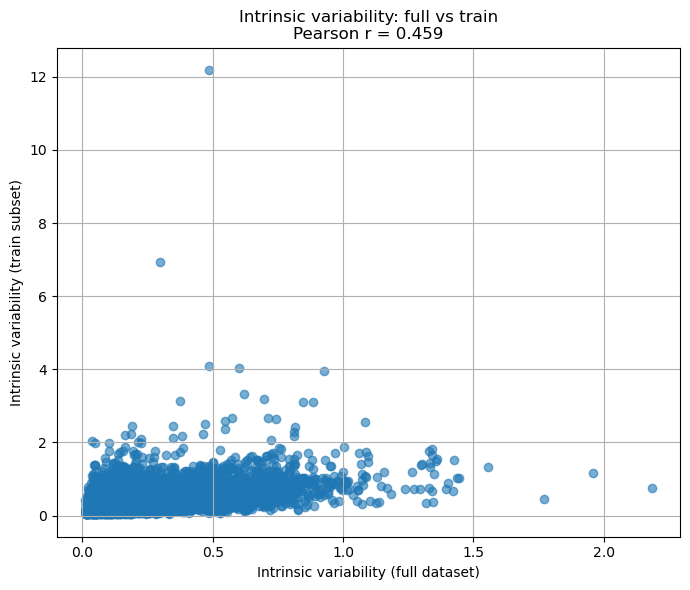

Pearson correlation: 0.4589
N points: 14300


In [8]:
import matplotlib.pyplot as plt

plot_df = eval_seed_df[
    ["variability_intrinsic", "variability_intrinsic_train"]
].dropna().copy()

corr = plot_df["variability_intrinsic"].corr(plot_df["variability_intrinsic_train"])

plt.figure(figsize=(7, 6))
plt.scatter(
    plot_df["variability_intrinsic"],
    plot_df["variability_intrinsic_train"],
    alpha=0.6
)

plt.xlabel("Intrinsic variability (full dataset)")
plt.ylabel("Intrinsic variability (train subset)")
plt.title(f"Intrinsic variability: full vs train\nPearson r = {corr:.3f}")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Pearson correlation: {corr:.4f}")
print(f"N points: {len(plot_df)}")

In [9]:
train_rows = []

train_files = sorted(BASE_DIR.glob("*/results/train_*_scaled/seed_*_scaled/train_subset_*_seed*.csv"))
print(f"Found {len(train_files)} training subset files")

for f in tqdm(train_files):
    experiment = f.parts[-5]  # .../experiments/{experiment}/results/train_x_scaled/seed_y_scaled/file.csv
    psu_num, seed_num = extract_psu_seed_from_train(f)
    if psu_num is None or seed_num is None:
        continue

    try:
        df = pd.read_csv(f)
    except Exception as e:
        print(f"Skipping train file {f} because of read error: {e}")
        continue

    adm1_col = detect_adm1_col(df, ["adm1name", "adm1_name", "Code_adm1"])
    if adm1_col is None:
        print(f"Skipping train file {f}: no adm1 column found")
        continue

    counts = (
        df.groupby(adm1_col, dropna=False)
          .size()
          .reset_index(name="n_train")
          .rename(columns={adm1_col: "adm1"})
    )

    counts["adm1"] = counts["adm1"].astype(str)
    counts["experiment"] = experiment
    counts["psu_num"] = psu_num
    counts["seed"] = seed_num

    train_rows.append(counts[["experiment", "psu_num", "seed", "adm1", "n_train"]])

train_seed_counts_df = pd.concat(train_rows, ignore_index=True) if train_rows else pd.DataFrame()
print(train_seed_counts_df.shape)
train_seed_counts_df.head()

Found 320 training subset files


  0%|          | 0/320 [00:00<?, ?it/s]

100%|██████████| 320/320 [00:05<00:00, 56.16it/s]

(2920, 5)


,experiment,psu_num,seed,adm1,n_train
0,eth_micron,1,1,Addis Ababa,15
1,eth_micron,1,1,Afar,10
2,eth_micron,1,1,Amhara,11
3,eth_micron,1,1,B. Gumuz,15
4,eth_micron,1,1,Dire Dawa,15


In [10]:
seed_level_df = eval_seed_df.merge(
    train_seed_counts_df,
    on=["experiment", "psu_num", "seed", "adm1"],
    how="left"
)

print(seed_level_df.shape)
seed_level_df.head()

(14300, 12)


,experiment,psu_num,seed,adm1,adm1_code_used,variable,improvement,variability_intrinsic,variability_intrinsic_train,emd_gen,emd_nat,n_train
0,eth_micron,1,1,Addis Ababa,Addis Ababa,va_ai,-0.130903,0.214577,0.710779,0.312715,0.181812,15
1,eth_micron,1,1,Addis Ababa,Addis Ababa,fol_ai,0.039488,0.112310,0.535538,0.373447,0.412934,15
2,eth_micron,1,1,Addis Ababa,Addis Ababa,vb12_ai,-0.674689,0.180890,0.851840,0.782882,0.108193,15
3,eth_micron,1,1,Addis Ababa,Addis Ababa,fe_ai,0.128043,0.215984,0.371344,0.115920,0.243963,15
4,eth_micron,1,1,Addis Ababa,Addis Ababa,zn_ai,0.142539,0.207562,0.535659,0.227432,0.369971,15


In [11]:
missing_train = seed_level_df["n_train"].isna().sum()
print(f"Rows with missing n_train after merge: {missing_train}")

if missing_train > 0:
    display(
        seed_level_df.loc[seed_level_df["n_train"].isna(),
                          ["experiment", "psu_num", "seed", "adm1", "variable"]]
        .drop_duplicates()
        .sort_values(["experiment", "psu_num", "seed", "adm1", "variable"])
        .head(50)
    )

Rows with missing n_train after merge: 0


In [14]:
final_df = (
    seed_level_df
    .groupby(["experiment", "adm1", "variable", "psu_num"], dropna=False)
    .agg(
        n_seeds=("seed", "nunique"),
        improvement_mean=("improvement", "mean"),
        improvement_std=("improvement", "std"),
        variability_intrinsic_mean=("variability_intrinsic_train", "mean"),
        variability_intrinsic_std=("variability_intrinsic", "std"),
        n_train_mean=("n_train", "mean"),
        n_train_std=("n_train", "std"),
        emd_gen_mean=("emd_gen", "mean"),
        emd_nat_mean=("emd_nat", "mean"),
    )
    .reset_index()
)

# if only one seed exists in a group, std will be NaN -> replace with 0
std_cols = [
    "improvement_std",
    "variability_intrinsic_std",
    "n_train_std",
]
final_df[std_cols] = final_df[std_cols].fillna(0)

final_df = final_df.sort_values(
    ["experiment", "adm1", "variable", "psu_num"]
).reset_index(drop=True)

print(final_df.shape)
final_df.head()

(2860, 13)


,experiment,adm1,variable,psu_num,n_seeds,improvement_mean,improvement_std,variability_intrinsic_mean,variability_intrinsic_std,n_train_mean,n_train_std,emd_gen_mean,emd_nat_mean
0,eth_micron,Addis Ababa,avg_adult_education,1,5,0.590759,0.409287,0.876903,0.233005,15.0,0.000000,0.184123,0.774883
1,eth_micron,Addis Ababa,avg_adult_education,2,5,0.516941,0.348304,0.884816,0.202001,29.6,14.758049,0.183620,0.700561
2,eth_micron,Addis Ababa,avg_adult_education,4,5,0.465627,0.181572,0.743971,0.085459,50.2,13.330416,0.140340,0.605967
3,eth_micron,Addis Ababa,avg_adult_education,8,5,0.449265,0.160634,0.621071,0.072853,118.2,24.843510,0.154969,0.604233
4,eth_micron,Addis Ababa,fe_ai,1,5,-0.115664,0.298354,0.601189,0.036166,15.0,0.000000,0.346497,0.230833


In [15]:
final_df.to_csv(OUTPUT_DIR / "adm1_level_summary.csv", index=False)